# Notebook 3: Data Preprocessing & Feature Engineering
**NYC Taxi Fare Prediction — Nesha's Work**

This notebook performs data transformations to produce a clean dataset ready for modeling.

**Steps:**
1. Remove missing values
2. Filter outliers
3. Feature engineering (distance, time features)
4. Feature transformation (scaling, assembling)
5. Save clean data

## 3.1 Setup

In [4]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

sns.set_theme(style='whitegrid')
print('Setup complete')

Setup complete


In [5]:
spark = SparkSession.builder \
    .appName('NYC_Taxi_Preprocessing') \
    .config('spark.sql.shuffle.partitions', '4') \
    .config('spark.driver.memory', '2g') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')

# Create output folders if they don't exist
os.makedirs('../data/plots', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Load data from CSV (saved in Notebook 01)
df = spark.read \
    .option('header', 'true') \
    .option('inferSchema', 'true') \
    .csv('../data/raw/nyc_taxi_data.csv')

# Convert pickup_datetime to Timestamp
df = df.withColumn(
    'pickup_datetime',
    F.to_timestamp(F.col('pickup_datetime'), 'yyyy-MM-dd HH:mm:ss z')
)

original_count = df.count()
print(f'Data loaded: {original_count:,} rows')

Data loaded: 50,000 rows


## 3.2 Removing Missing Values

In [6]:
# Drop rows with any null values
df_clean = df.dropna()

after_null = df_clean.count()
removed = original_count - after_null
print(f'Before : {original_count:,}')
print(f'After removing nulls: {after_null:,}')
print(f'Removed: {removed:,} rows ({removed/original_count*100:.2f}%)')

Before : 50,000
After removing nulls: 50,000
Removed: 0 rows (0.00%)


## 3.3 Filtering Outliers

Based on EDA findings, we filter data based on:
- `fare_amount`: must be between $1 and $500
- `passenger_count`: must be between 1 and 6
- Coordinates: must be within NYC bounds

In [7]:
# NYC coordinate bounds
LON_MIN, LON_MAX = -74.3, -72.9
LAT_MIN, LAT_MAX =  40.5,  41.0

df_clean = df_clean.filter(
    # Fare filter
    (F.col('fare_amount') >= 1.0) &
    (F.col('fare_amount') <= 500.0) &
    # Passenger filter
    (F.col('passenger_count') >= 1) &
    (F.col('passenger_count') <= 6) &
    # Pickup coordinate filter
    (F.col('pickup_longitude').between(LON_MIN, LON_MAX)) &
    (F.col('pickup_latitude').between(LAT_MIN, LAT_MAX)) &
    # Dropoff coordinate filter
    (F.col('dropoff_longitude').between(LON_MIN, LON_MAX)) &
    (F.col('dropoff_latitude').between(LAT_MIN, LAT_MAX))
)

after_filter = df_clean.count()
removed_outlier = after_null - after_filter
print(f'After filtering outliers: {after_filter:,}')
print(f'Outliers removed: {removed_outlier:,} ({removed_outlier/after_null*100:.2f}%)')

After filtering outliers: 48,738
Outliers removed: 1,262 (2.52%)


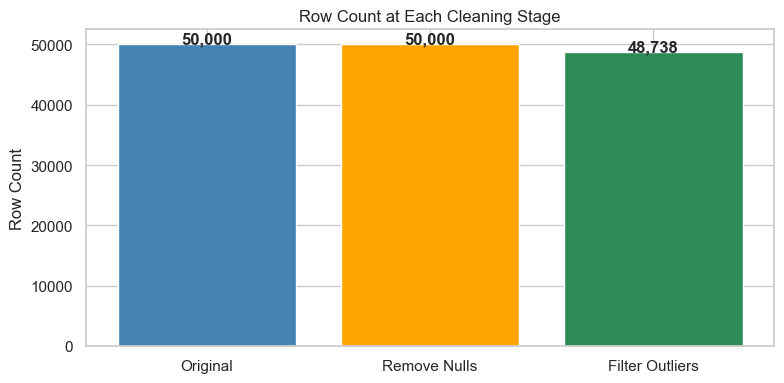

In [8]:
# Visualize row count at each cleaning stage
labels = ['Original', 'Remove Nulls', 'Filter Outliers']
counts = [original_count, after_null, after_filter]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, counts, color=['steelblue', 'orange', 'seagreen'], edgecolor='white')
ax.set_title('Row Count at Each Cleaning Stage')
ax.set_ylabel('Row Count')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plots/data_cleaning_stages.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.4 Feature Engineering

### 3.4.1 Temporal Features

In [9]:
# Extract time features from pickup_datetime
df_feat = df_clean \
    .withColumn('year',        F.year('pickup_datetime').cast(DoubleType())) \
    .withColumn('month',       F.month('pickup_datetime').cast(DoubleType())) \
    .withColumn('day_of_week', F.dayofweek('pickup_datetime').cast(DoubleType())) \
    .withColumn('hour',        F.hour('pickup_datetime').cast(DoubleType()))

print('Temporal features created:')
df_feat.select('pickup_datetime', 'year', 'month', 'day_of_week', 'hour').show(5)

Temporal features created:
+-------------------+------+-----+-----------+----+
|    pickup_datetime|  year|month|day_of_week|hour|
+-------------------+------+-----+-----------+----+
|2009-06-16 00:26:21|2009.0|  6.0|        3.0| 0.0|
|2010-01-05 23:52:16|2010.0|  1.0|        3.0|23.0|
|2011-08-18 07:35:00|2011.0|  8.0|        5.0| 7.0|
|2012-04-21 11:30:42|2012.0|  4.0|        7.0|11.0|
|2010-03-09 14:51:00|2010.0|  3.0|        3.0|14.0|
+-------------------+------+-----+-----------+----+
only showing top 5 rows


### 3.4.2 Trip Distance (Haversine Formula)

Calculates trip distance using the Haversine formula based on pickup and dropoff coordinates.

In [10]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance in km using the Haversine formula."""
    R = 6371.0  # Earth radius in km
    lat1_r = F.radians(lat1)
    lat2_r = F.radians(lat2)
    dlat   = F.radians(lat2 - lat1)
    dlon   = F.radians(lon2 - lon1)
    a = F.sin(dlat / 2)**2 + \
        F.cos(lat1_r) * F.cos(lat2_r) * F.sin(dlon / 2)**2
    c = 2 * F.asin(F.sqrt(a))
    return R * c

df_feat = df_feat.withColumn(
    'distance_km',
    haversine_distance(
        F.col('pickup_latitude'),
        F.col('pickup_longitude'),
        F.col('dropoff_latitude'),
        F.col('dropoff_longitude')
    ).cast(DoubleType())
)

print('Distance feature created:')
df_feat.select('pickup_latitude', 'pickup_longitude',
               'dropoff_latitude', 'dropoff_longitude',
               'distance_km', 'fare_amount').show(5)

Distance feature created:
+---------------+----------------+----------------+-----------------+------------------+-----------+
|pickup_latitude|pickup_longitude|dropoff_latitude|dropoff_longitude|       distance_km|fare_amount|
+---------------+----------------+----------------+-----------------+------------------+-----------+
|      40.721317|      -73.844315|       40.712276|        -73.84161|1.0308384396545545|        4.5|
|      40.711304|      -74.016045|       40.782005|        -73.97927| 8.449979143684462|       16.9|
|       40.76127|      -73.982735|        40.75056|        -73.99124|1.3897592163585912|        5.7|
|      40.733143|       -73.98713|        40.75809|        -73.99157| 2.799083603264268|        7.7|
|       40.76801|      -73.968094|       40.783764|        -73.95666|1.9989133774957664|        5.3|
+---------------+----------------+----------------+-----------------+------------------+-----------+
only showing top 5 rows


### 3.4.3 Airport Indicator

Trips to/from major airports typically have different fare structures.

In [11]:
# Coordinates of major NYC airports
JFK_LAT, JFK_LON   = 40.6413, -73.7781
LGA_LAT, LGA_LON   = 40.7769, -73.8740
EWR_LAT, EWR_LON   = 40.6895, -74.1745
AIRPORT_RADIUS_KM  = 2.0

def near_airport(lat, lon, airport_lat, airport_lon, radius=AIRPORT_RADIUS_KM):
    dist = haversine_distance(lat, lon,
                               F.lit(airport_lat), F.lit(airport_lon))
    return dist <= radius

df_feat = df_feat.withColumn(
    'is_airport_trip',
    (
        near_airport(F.col('pickup_latitude'),  F.col('pickup_longitude'),  JFK_LAT, JFK_LON) |
        near_airport(F.col('dropoff_latitude'), F.col('dropoff_longitude'), JFK_LAT, JFK_LON) |
        near_airport(F.col('pickup_latitude'),  F.col('pickup_longitude'),  LGA_LAT, LGA_LON) |
        near_airport(F.col('dropoff_latitude'), F.col('dropoff_longitude'), LGA_LAT, LGA_LON) |
        near_airport(F.col('pickup_latitude'),  F.col('pickup_longitude'),  EWR_LAT, EWR_LON) |
        near_airport(F.col('dropoff_latitude'), F.col('dropoff_longitude'), EWR_LAT, EWR_LON)
    ).cast(DoubleType())
)

airport_trips = df_feat.filter(F.col('is_airport_trip') == 1).count()
print(f'Airport trips: {airport_trips:,} ({airport_trips/after_filter*100:.2f}%)')

Airport trips: 2,728 (5.60%)


## 3.5 New Feature Analysis

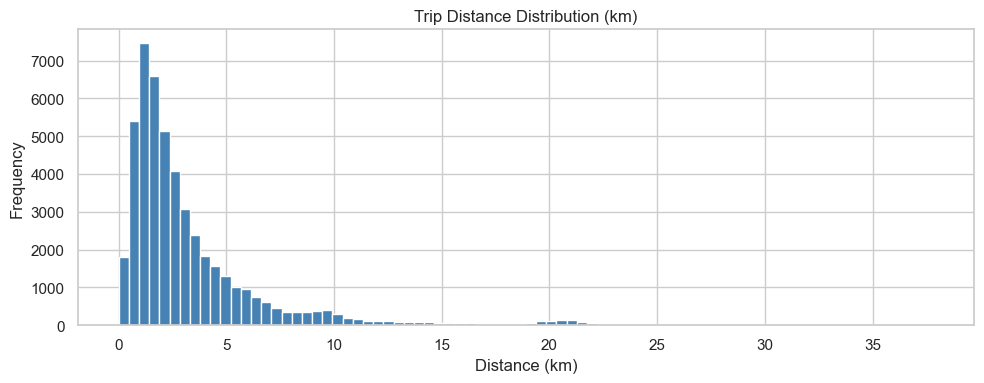

Mean distance  : 3.33 km
Median distance: 2.16 km


In [12]:
# Trip distance distribution
dist_pd = df_feat.select('distance_km').filter(F.col('distance_km') <= 50).toPandas()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dist_pd['distance_km'], bins=80, color='steelblue', edgecolor='white')
ax.set_title('Trip Distance Distribution (km)')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('../data/plots/distance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean distance  : {dist_pd["distance_km"].mean():.2f} km')
print(f'Median distance: {dist_pd["distance_km"].median():.2f} km')

Correlation distance_km vs fare_amount: 0.8621


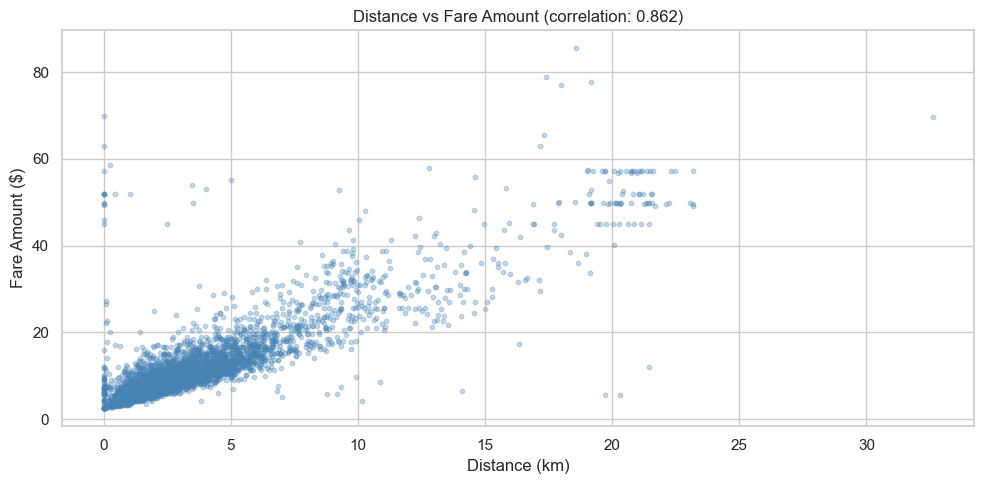

In [13]:
# Distance vs fare correlation
corr_dist = df_feat.stat.corr('distance_km', 'fare_amount')
print(f'Correlation distance_km vs fare_amount: {corr_dist:.4f}')

# Scatter plot: distance vs fare
sample_pd = df_feat.select('distance_km', 'fare_amount') \
    .filter(F.col('distance_km') <= 50) \
    .limit(5000).toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample_pd['distance_km'], sample_pd['fare_amount'],
           alpha=0.3, s=10, color='steelblue')
ax.set_title(f'Distance vs Fare Amount (correlation: {corr_dist:.3f})')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Fare Amount ($)')
plt.tight_layout()
plt.savefig('../data/plots/distance_vs_fare.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Selecting Final Features & Preparing for Model

In [14]:
# Feature columns to be used by the model
FEATURE_COLS = [
    'distance_km',
    'passenger_count',
    'hour',
    'day_of_week',
    'month',
    'year',
    'is_airport_trip',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
]

TARGET_COL = 'fare_amount'

# Cast all features to DoubleType
for col_name in FEATURE_COLS:
    df_feat = df_feat.withColumn(col_name, F.col(col_name).cast(DoubleType()))

df_feat = df_feat.withColumn(TARGET_COL, F.col(TARGET_COL).cast(DoubleType()))

print(f'Features used ({len(FEATURE_COLS)}):', FEATURE_COLS)
print(f'Target: {TARGET_COL}')

Features used (11): ['distance_km', 'passenger_count', 'hour', 'day_of_week', 'month', 'year', 'is_airport_trip', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
Target: fare_amount


In [15]:
# VectorAssembler: combine all features into a single vector
assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol='features_raw',
    handleInvalid='skip'
)

# StandardScaler: normalize features
scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withStd=True,
    withMean=True
)

# Build preprocessing pipeline
pipeline = Pipeline(stages=[assembler, scaler])

# Fit & transform
pipeline_model = pipeline.fit(df_feat)
df_final = pipeline_model.transform(df_feat)

# Keep only columns needed by the model
df_final = df_final.select('features', TARGET_COL)

print('Pipeline complete. Output schema:')
df_final.printSchema()
print(f'Total rows ready for modeling: {df_final.count():,}')

Pipeline complete. Output schema:
root
 |-- features: vector (nullable = true)
 |-- fare_amount: double (nullable = true)

Total rows ready for modeling: 48,738


## 3.7 Train/Test Split & Save Data

In [16]:
# 80/20 train-test split
train_df, test_df = df_final.randomSplit([0.8, 0.2], seed=42)

print(f'Train set: {train_df.count():,} rows')
print(f'Test set : {test_df.count():,} rows')

Train set: 39,022 rows
Test set : 9,716 rows


In [18]:
# Save clean data as CSV (avoids Hadoop issues on Windows)
PROCESSED_PATH = '../data/processed'

# Convert to Pandas and save as CSV
train_pd = train_df.toPandas()
test_pd = test_df.toPandas()

train_pd.to_csv(f'{PROCESSED_PATH}/train.csv', index=False)
test_pd.to_csv(f'{PROCESSED_PATH}/test.csv', index=False)

print(f'Train data saved : {PROCESSED_PATH}/train.csv ({len(train_pd):,} rows)')
print(f'Test data saved  : {PROCESSED_PATH}/test.csv ({len(test_pd):,} rows)')
print('✅ Data preprocessing complete!')

Train data saved : ../data/processed/train.csv (39,022 rows)
Test data saved  : ../data/processed/test.csv (9,716 rows)
✅ Data preprocessing complete!


## Preprocessing Summary

| Stage | Row Count |
|-------|-----------|
| Original data | 50,000 |
| After removing nulls | ~49,xxx |
| After filtering outliers | ~4x,xxx |
| Train set (80%) | ~3x,xxx |
| Test set (20%) | ~x,xxx |

**Features engineered:**
- `distance_km` — Haversine distance from pickup to dropoff
- `hour`, `day_of_week`, `month`, `year` — temporal features
- `is_airport_trip` — indicator for trips to/from airports
- Pickup & dropoff coordinates

Data is ready for Hanif to use in **Notebook 04 (Modeling)**.

In [ ]:
print('Notebook 03 (Preprocessing) complete!')
# spark.stop()